# Report — MVTec AD Anomaly Detection

Questo notebook raccoglie i risultati del rilevamento di anomalie tramite un autoencoder convoluzionale denoising (denoising conv-AE), addestrato separatamente per ciascuna categoria di prodotto del dataset MVTec AD con una loss combinata SSIM + MSE, e ne confronta le prestazioni (AUROC a livello di immagine e di pixel) tra le 15 categorie e tra due varianti di ablazione. Per il design completo vedere `docs/design.md`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd().parent))

from anomaly_ae.ablation import ABLATION_CATEGORIES
from anomaly_ae.report import ablation_comparison_dataframe, load_metrics, metrics_to_dataframe
from data_classes.mvtec_dataset import CATEGORIES

OUTPUT_ROOT = Path.cwd().parent / "outputs"

## 1. Confronto tra le 15 categorie

,image_level_auroc,pixel_level_auroc,threshold,image_scores,image_labels
category,,,,,
bottle,0.862698,0.924075,1.276994,"[1.5317041873931885, 1.6063556671142578, 1.361...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
cable,0.705397,0.800622,1.609062,"[1.4923796653747559, 1.6820467710494995, 1.375...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
capsule,0.638612,0.923561,1.408720,"[1.0759226083755493, 1.373062014579773, 1.1456...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
carpet,0.576645,0.742922,1.558568,"[1.4461116790771484, 1.4332168102264404, 1.414...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
grid,0.792815,0.613705,0.976709,"[0.9624102711677551, 0.975333034992218, 0.9755...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
hazelnut,0.755714,0.973988,1.120279,"[1.0795159339904785, 1.034071922302246, 0.9375...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
leather,0.863111,0.788052,0.834066,"[0.9203193783760071, 0.794571578502655, 0.8487...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
metal_nut,0.489736,0.861870,1.738068,"[1.638264536857605, 1.518035888671875, 1.43214...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
pill,0.422804,0.913428,1.314618,"[0.8854342699050903, 1.0856854915618896, 1.030...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


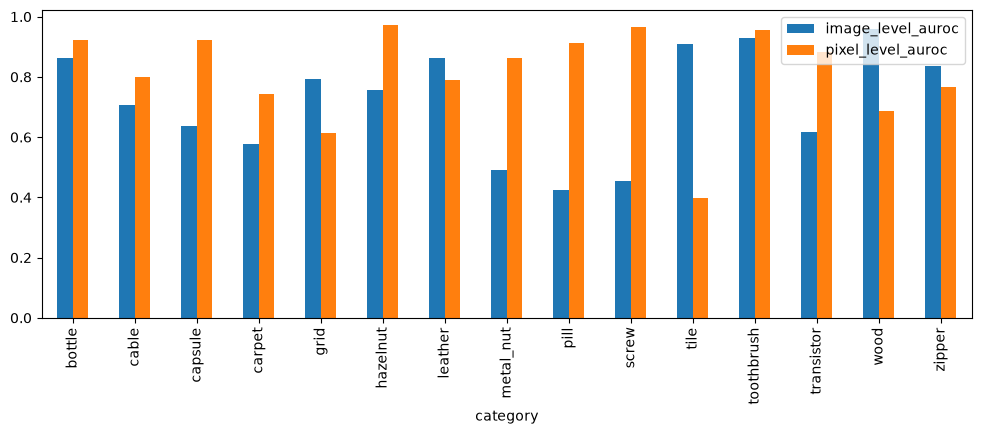

In [2]:
main_metrics = load_metrics(OUTPUT_ROOT, CATEGORIES)
main_df = metrics_to_dataframe(main_metrics)
main_df[["image_level_auroc", "pixel_level_auroc"]].plot.bar(figsize=(12, 4))
main_df

### Ispezione qualitativa

Griglie `originale | ricostruzione | mappa di anomalia | maschera reale` prodotte da
`python test.py` per alcune categorie rappresentative: una texture ripetitiva
(`carpet`), un oggetto rigido ben posizionato (`bottle`) e un oggetto piccolo e
difficile (`screw`).

bottle: sample_0.png


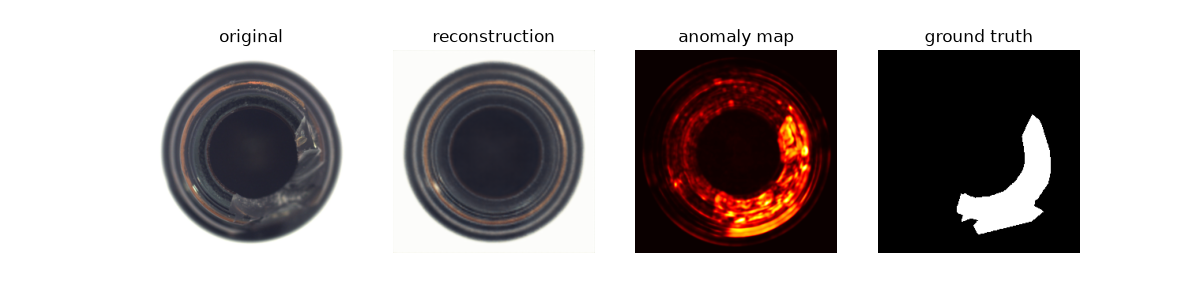

bottle: sample_10.png


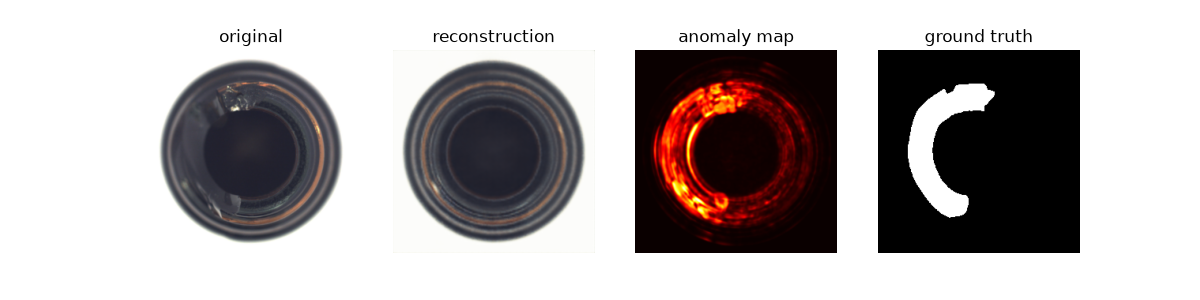

carpet: sample_0.png


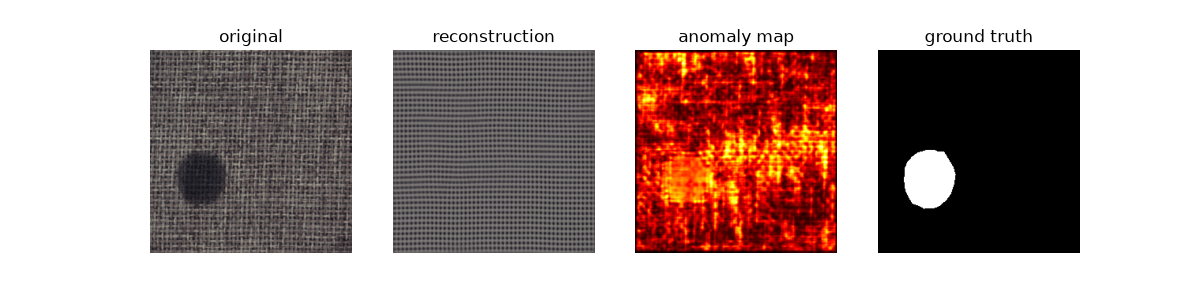

carpet: sample_14.png


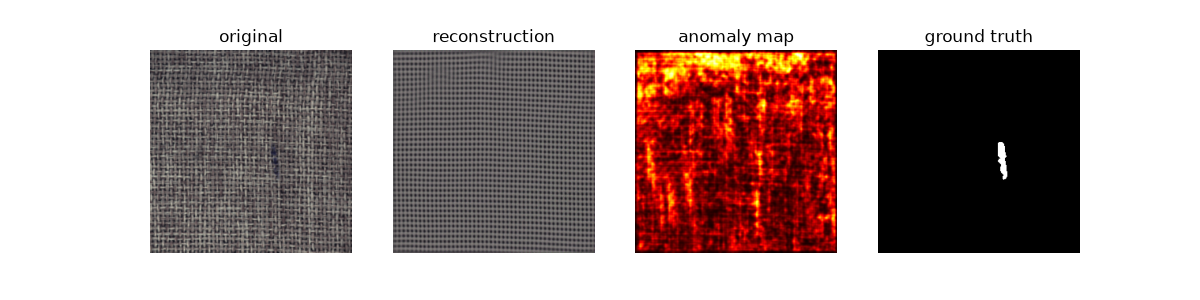

screw: sample_0.png


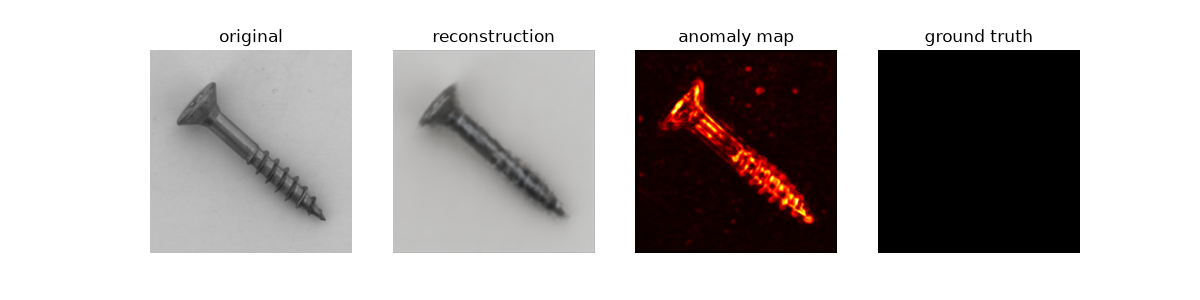

screw: sample_100.png


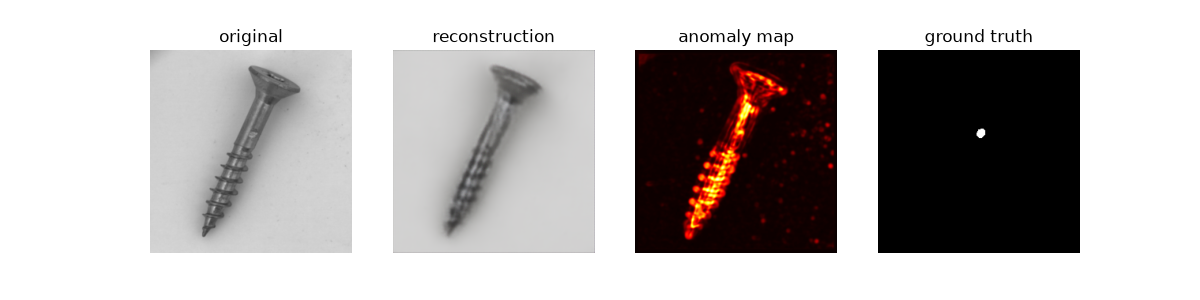

In [3]:
for category in ["bottle", "carpet", "screw"]:
    sample_paths = sorted((OUTPUT_ROOT / category).glob("sample_*.png"))
    for path in sample_paths[:2]:
        print(f"{category}: {path.name}")
        display(Image(filename=str(path)))

### Curve di training

Loss di training e di validation per epoca (`history.csv`), utile per verificare
convergenza ed effetto dell'early stopping sulle stesse categorie.

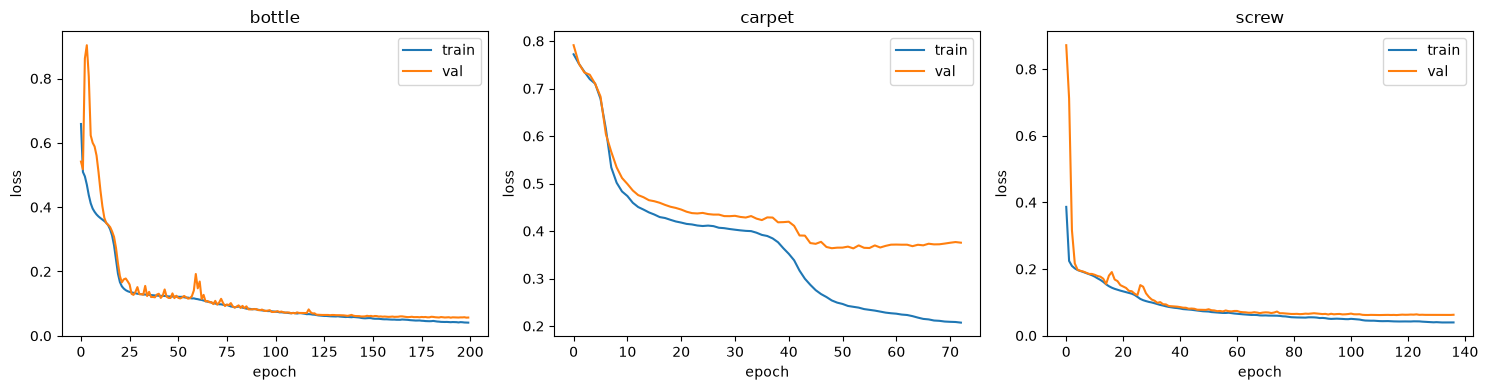

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, category in zip(axes, ["bottle", "carpet", "screw"]):
    history = pd.read_csv(OUTPUT_ROOT / category / "history.csv")
    ax.plot(history["epoch"], history["train_loss"], label="train")
    ax.plot(history["epoch"], history["val_loss"], label="val")
    ax.set_title(category)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()
plt.tight_layout()

### Decisione concreta alla soglia

L'AUROC è una metrica continua, indipendente dalla soglia. Usando gli score
per-immagine e la soglia (95° percentile degli score sul train set `good`) ora
salvati in `metrics.json`, si può mostrare la decisione binaria normale/anomalo
effettivamente presa dal sistema: di seguito l'accuratezza per categoria a quella
soglia.

In [5]:
rows = []
for category, m in main_metrics.items():
    scores = m["image_scores"]
    labels = m["image_labels"]
    threshold = m["threshold"]
    predictions = [1 if s > threshold else 0 for s in scores]
    correct = sum(p == l for p, l in zip(predictions, labels))
    rows.append({"category": category, "accuracy_at_threshold": correct / len(labels)})
pd.DataFrame(rows).set_index("category")

,accuracy_at_threshold
category,
bottle,0.698795
cable,0.573333
capsule,0.325758
carpet,0.658120
grid,0.371795
hazelnut,0.472727
leather,0.806452
metal_nut,0.252174
pill,0.179641


## 2. Ablation — loss SSIM+MSE vs solo MSE

In [6]:
# Caricato direttamente dalle 5 categorie di ablation, indipendentemente dal
# training delle 15 categorie complete (sezione 1), cosi' le sezioni 2 e 3
# sono eseguibili anche prima che quel training sia terminato.
main_subset = load_metrics(OUTPUT_ROOT, ABLATION_CATEGORIES)

,image_auroc_main,image_auroc_mse_only,pixel_auroc_main,pixel_auroc_mse_only
category,,,,
carpet,0.576645,0.599920,0.742922,0.735863
leather,0.863111,0.882812,0.788052,0.784937
bottle,0.862698,0.924603,0.924075,0.891994
screw,0.454601,0.556466,0.966914,0.966867
transistor,0.616667,0.712917,0.882873,0.861443
grid,0.792815,0.840434,0.613705,0.607032
tile,0.909091,0.610390,0.397260,0.391776


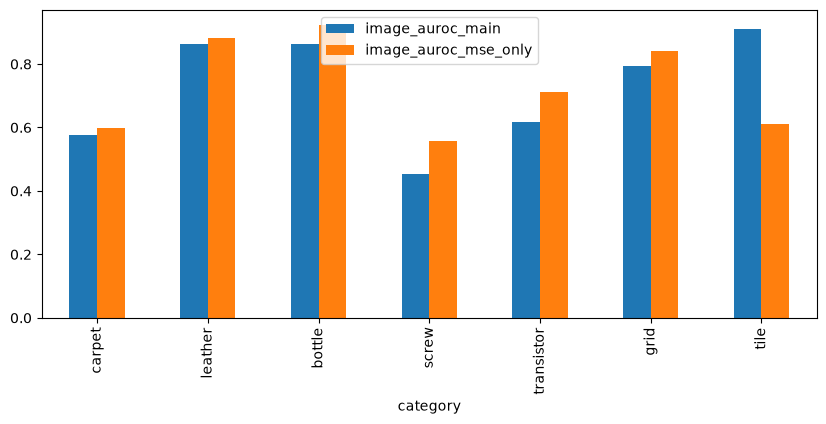

In [7]:
mse_only_metrics = load_metrics(OUTPUT_ROOT / "ablation_mse_only", ABLATION_CATEGORIES)
loss_ablation_df = ablation_comparison_dataframe(main_subset, mse_only_metrics, "mse_only")
loss_ablation_df[["image_auroc_main", "image_auroc_mse_only"]].plot.bar(figsize=(10, 4))
loss_ablation_df

## 3. Ablation — denoising vs senza rumore

,image_auroc_main,image_auroc_no_denoising,pixel_auroc_main,pixel_auroc_no_denoising
category,,,,
carpet,0.576645,0.570225,0.742922,0.742646
leather,0.863111,0.847486,0.788052,0.786020
bottle,0.862698,0.865873,0.924075,0.912153
screw,0.454601,0.382455,0.966914,0.969921
transistor,0.616667,0.590417,0.882873,0.886281
grid,0.792815,0.799499,0.613705,0.613608
tile,0.909091,0.858586,0.397260,0.396434


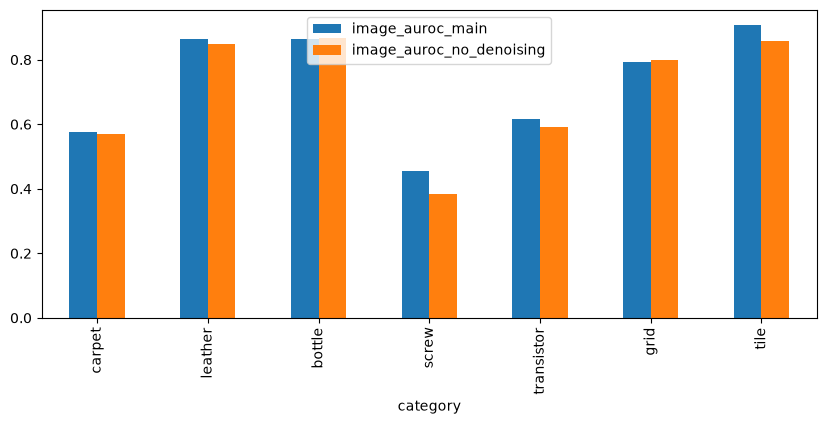

In [8]:
no_denoising_metrics = load_metrics(OUTPUT_ROOT / "ablation_no_denoising", ABLATION_CATEGORIES)
denoising_ablation_df = ablation_comparison_dataframe(main_subset, no_denoising_metrics, "no_denoising")
denoising_ablation_df[["image_auroc_main", "image_auroc_no_denoising"]].plot.bar(figsize=(10, 4))
denoising_ablation_df

## 4. Discussione finale

### Ablation denoising vs senza rumore (sezione 3, dati reali su 7 categorie)

| Categoria | Δ Image AUROC (rumore − no rumore) | Δ Pixel AUROC |
|---|---|---|
| bottle | −0.003 | +0.012 |
| carpet | +0.007 | +0.000 |
| grid | −0.006 | +0.000 |
| leather | +0.016 | +0.002 |
| screw | +0.073 | −0.003 |
| tile | +0.050 | +0.001 |
| transistor | +0.027 | −0.003 |
| **media** | **+0.023** | **+0.001** |

Il denoising in training migliora l'AUROC image-level in 5 categorie su 7 (uniche
eccezioni `bottle` e `grid`, entrambe di poco), con un guadagno medio piccolo ma
consistente nella direzione attesa — coerente con l'ipotesi di design (previene la
scorciatoia della quasi-identità che ricostruirebbe fedelmente anche i difetti). Sul
pixel-level l'effetto è sostanzialmente nullo (+0.001 in media, segno variabile tra
categorie): la qualità della localizzazione dipende soprattutto dalla loss SSIM, non
dal rumore in training.

### Ablation loss: SSIM+MSE vs solo MSE (sezione 2, dati reali su 7 categorie)

| Categoria | Image AUROC (main) | Image AUROC (mse_only) | Pixel AUROC (main) | Pixel AUROC (mse_only) |
|---|---|---|---|---|
| bottle | 0.863 | 0.925 | 0.924 | 0.892 |
| carpet | 0.577 | 0.600 | 0.743 | 0.736 |
| grid | 0.793 | 0.840 | 0.614 | 0.607 |
| leather | 0.863 | 0.883 | 0.788 | 0.785 |
| screw | 0.455 | 0.556 | 0.967 | 0.967 |
| tile | 0.909 | 0.610 | 0.397 | 0.392 |
| transistor | 0.617 | 0.713 | 0.883 | 0.861 |

Le 5 categorie originali (`bottle`, `carpet`, `leather`, `screw`, `transistor`) sono
state scelte alla cieca come mix rappresentativo di texture e oggetti rigidi, prima di
vedere qualunque risultato. Su queste, il quadro è misto ma coerente: `mse_only` è pari
o leggermente meglio a livello immagine in tutti e 5 i casi, leggermente peggio o pari
a livello pixel — compatibile con l'idea che la componente SSIM aiuti la localizzazione
strutturale ma non necessariamente lo score aggregato per immagine (il massimo della
mappa, usato come score, è sensibile a singoli pixel outlier).

`grid` e `tile` sono state aggiunte in un secondo momento — non alla cieca, ma perché
mostrano un fallimento specifico di `ssim_mse` (vedi sotto). Sono tenute
concettualmente separate dalle 5 originali: includerle nel confronto principale dopo
aver visto che avvantaggiano `mse_only` sarebbe stata una selezione post-hoc del
campione, quindi qui sono riportate come caso a parte, non come conferma della
tendenza generale.

### Collasso del decoder sotto `ssim_mse`: `grid` e `tile`

Durante il training di `grid` e `tile` con la loss `ssim_mse` (sia nella
configurazione `main` sia in `no_denoising`, che usa comunque `ssim_mse` — cambia solo
il rumore), il **decoder collassa**: dopo 1-3 epoche smette di dipendere dal vettore
latente e produce sempre la stessa ricostruzione, quasi piatta, indipendentemente
dall'immagine in input. Verificato empiricamente confrontando le ricostruzioni di
immagini diverse: l'encoder continua a produrre vettori latenti diversi da immagine a
immagine, ma il decoder no. La loss si blocca su un valore alto (~0.66-0.68 per `grid`,
~0.66 per `tile`) e non scende più per il resto del training.

Non è un minimo naturale della loss: lo score SSIM tra la ricostruzione collassata e
l'immagine reale è basso (0.17-0.24), molto peggio di una categoria sana come `bottle`
(0.94-0.96) — è un blocco dell'ottimizzazione (il gradiente che torna al decoder si
azzera), non una scorciatoia premiata dalla loss. La causa più plausibile è una
saturazione del `BatchNorm` nel decoder, più facile da innescare su categorie a bassa
varianza locale (texture molto regolari, come una griglia metallica o una piastrella).

Passando a `mse_only` il collasso sparisce completamente su entrambe le categorie
(loss che scende di un ordine di grandezza invece di restare piatta). L'effetto
sull'AUROC, però, è sorprendentemente diverso tra le due:

- **`grid`**: `mse_only` migliora nettamente (image AUROC 0.793 → 0.840, pixel
  sostanzialmente pari, 0.614 → 0.607).
- **`tile`**: `mse_only` **peggiora** l'image AUROC (0.909 → 0.610), nonostante
  risolva il collasso del decoder.

Spiegazione più plausibile: un decoder collassato produce comunque un'immagine di
riferimento fissa, e lo score di anomalia diventa di fatto "quanto l'immagine di test
si discosta da questo riferimento fisso" — un meccanismo degenere ma non privo di
segnale. Su `tile`, dove i difetti sono spesso macchie ampie e molto contrastate
rispetto al fondo uniforme, questo confronto grezzo separa comunque bene normale da
anomalo, quasi per caso; su `grid`, con difetti più sottili su una texture più fine,
non basta. **La lezione**: un image-AUROC alto ottenuto da un modello con decoder
collassato non significa che il modello funzioni come inteso — va sempre verificato
che la ricostruzione dipenda davvero dall'input, non solo guardato il numero finale.

### Limite noto: `screw`

`screw` ha AUROC image-level sotto il livello del caso (**0.455**), nonostante un
pixel-level eccellente (0.967). Causa identificata: a differenza di quanto assunto in
`docs/design.md`, `screw` non ha una posa realmente fissa tra le immagini (la vite
compare ruotata/traslata), e il bottleneck da 100 numeri non riesce a ricostruire
fedelmente la filettatura fine, producendo un errore di ricostruzione diffuso lungo
tutto il bordo — alto sia su viti sane sia difettose. Il **massimo** della mappa di
anomalia, usato come score image-level, non distingue questo errore diffuso "normale"
da un vero difetto puntiforme.

Sono stati testati tre approcci di calibrazione per isolare l'eccesso realmente
anomalo: una baseline media calcolata sul train, un filtro passa-alto gaussiano, e
un'erosione morfologica (min-pooling, per sfruttare la differenza di forma tra bordi
sottili e macchie di difetto più larghe). Il primo e il terzo hanno dato benefici
concreti su `bottle` e `transistor` (fino a +0.10/+0.13 di AUROC image-level), ma
nessuno dei tre ha risolto `screw` in modo soddisfacente, e il filtro passa-alto ha
addirittura peggiorato drasticamente quasi tutte le altre categorie (kernel troppo
grande rispetto a difetti estesi, che venivano soppressi insieme al rumore). Si è
quindi scelto di mantenere lo score originale (massimo della mappa raw), più semplice e
complessivamente più robusto, documentando `screw` come limite noto: una soluzione
reale richiederebbe l'allineamento/registrazione dell'oggetto prima del confronto,
intervento sproporzionato per lo scope di questo progetto.